#  Анализ рынка недвижимости Астаны
**Источник:** [Kaggle — Astana Real Estate Dataset](https://www.kaggle.com/datasets/turarr/astana-real-estate-dataset)

---

### Бизнес-вопросы
1. Какие районы самые дорогие по цене за м²?
2. Как площадь и количество комнат влияют на цену?
3. Новостройка vs вторичка — насколько велика разница?
4. Влияет ли этаж на стоимость?
5. Какой бюджет нужен для покупки 2-комнатной квартиры в разных районах?
6. Можно ли предсказать цену квартиры по её характеристикам?

## 0. Импорты и настройки

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- стиль ---
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
})
FMT_MLN = mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
FMT_K   = mticker.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K')

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 30)

## 1. Загрузка данных

In [31]:
# ⬇️ Скачай датасет с Kaggle и положи CSV рядом с ноутбуком
# https://www.kaggle.com/datasets/turarr/astana-real-estate-dataset

df_raw = pd.read_csv('astana_real_estate.csv')  # замени имя файла если нужно

print(f'Строк: {len(df_raw):,}   Колонок: {df_raw.shape[1]}')
print('\nКолонки:')
print(df_raw.columns.tolist())
df_raw.head(3)

Строк: 5,003   Колонок: 23

Колонки:
['url', 'title', 'price', 'security', 'ceiling_height', 'Год постройки', 'district', 'residential_complex', 'furnished', 'parking', 'bathroom_type', 'apartment_condition', 'building_type', 'rooms', 'current_floor', 'total_floors', 'area_m2', 'address', 'district_lat', 'district_lon', 'apartment_lat', 'apartment_lon', 'coord_level']


,url,title,price,security,ceiling_height,Год постройки,district,residential_complex,furnished,parking,bathroom_type,apartment_condition,building_type,rooms,current_floor,total_floors,area_m2,address,district_lat,district_lon,apartment_lat,apartment_lon,coord_level
0,https://krisha.kz/a/show/683656844,"3-комнатная квартира · 120 м², Сыганак — Кабан...",55000000,"домофон, видеонаблюдение",3,2006,"Есильский район, Астана, Казахстан",7 Бочек,полностью,Во дворе/не указано,2 с/у и более,свежий ремонт,монолитный,3,6,11,120,Сыганак — Кабанбай батыра,51,71,51,71,Address
1,https://krisha.kz/a/show/1010380882,"2-комнатная квартира · 64.5 м² · 9/9 этаж, Тол...",45500000,"домофон, видеонаблюдение",3,2022,"Нуринский район, Астана, Казахстан",Dastur,полностью,Во дворе/не указано,совмещенный,Не указано,кирпичный,2,9,9,64,Толе би 25,51,71,51,71,Complex
2,https://krisha.kz/a/show/1010251370,"2-комнатная квартира · 64.37 м² · 10/12 этаж, ...",32800000,"домофон, кодовый замок, видеодомофон",3,2026,"Сарыаркинский район, Астана, Казахстан",Shalqar,без мебели,паркинг,совмещенный,черновая отделка,кирпичный,2,10,12,64,Чингиз Айтматов 77/11 — Мечеть Ырыскелді Кажы,51,71,51,71,District


In [32]:
# Быстрый профиль данных
print('=== Типы данных ===')
print(df_raw.dtypes)
print('\n=== Пропуски (%) ===')
miss = df_raw.isnull().mean().mul(100).round(1)
print(miss[miss > 0].sort_values(ascending=False))
print('\n=== Базовая статистика ===')
df_raw.describe()

=== Типы данных ===
url                     object
title                   object
price                    int64
security                object
ceiling_height         float64
Год постройки            int64
district                object
residential_complex     object
furnished               object
parking                 object
bathroom_type           object
apartment_condition     object
building_type           object
rooms                  float64
current_floor          float64
total_floors           float64
area_m2                float64
address                 object
district_lat           float64
district_lon           float64
apartment_lat          float64
apartment_lon          float64
coord_level             object
dtype: object

=== Пропуски (%) ===
Series([], dtype: float64)

=== Базовая статистика ===


,price,ceiling_height,Год постройки,rooms,current_floor,total_floors,area_m2,district_lat,district_lon,apartment_lat,apartment_lon
count,"5,003","5,003","5,003","5,003","5,003","5,003","5,003","5,003","5,003","5,003","5,003"
mean,"54,132,515",3,"2,019",2,7,12,71,51,71,51,71
std,"479,861,309",1,10,1,4,5,38,0,0,0,0
min,"3,500,000",2,"1,959",1,1,2,10,51,71,51,71
25%,"27,500,000",3,"2,017",2,4,9,43,51,71,51,71
50%,"37,800,000",3,"2,022",2,6,11,63,51,71,51,71
75%,"55,000,000",3,"2,025",3,9,13,86,51,72,51,71
max,"33,900,000,000",27,"2,028",10,37,43,785,51,72,51,72


## 2. Приведение колонок и чистка данных

In [ ]:
# ─────────────────────────────────────────────────────────────────
# МАППИНГ КОЛОНОК
# Посмотри df_raw.columns и подправь словарь под свой датасет.
# Типичные варианты названий для Krisha.kz датасетов:
# ─────────────────────────────────────────────────────────────────
COLUMN_MAP = {
    'price':             'price',
    'area_m2':           'area',
    'rooms':             'rooms',
    'current_floor':     'floor',
    'total_floors':      'floor_total',
    'district':          'district',
    'Год постройки':     'year_built',
    'building_type':     'building_type',
    'apartment_condition': 'condition',
}


# Если нужно добавить ещё — просто допиши строку в словарь

df = df_raw.rename(columns=COLUMN_MAP).copy()

# Проверка что основные колонки есть
required = ['price', 'area', 'rooms', 'floor', 'floor_total', 'district']
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    print(f'  Не найдены колонки: {missing_cols}')
    print('Подправь COLUMN_MAP выше под реальные названия колонок')
else:
    print(' Все основные колонки найдены')

✅ Все основные колонки найдены


In [34]:
# ── Числовые типы ──
for col in ['price', 'area', 'rooms', 'floor', 'floor_total', 'year_built']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Вычисляемые поля ──
df['price_per_m2'] = df['price'] / df['area']

if 'year_built' in df.columns:
    df['building_age'] = 2024 - df['year_built']
    df['is_new']       = df['year_built'] >= 2015   # новостройка ≥ 2015

if 'floor' in df.columns and 'floor_total' in df.columns:
    df['is_first_floor'] = df['floor'] == 1
    df['is_last_floor']  = df['floor'] == df['floor_total']
    df['floor_ratio']    = df['floor'] / df['floor_total'].clip(lower=1)

print(f'Строк до чистки: {len(df):,}')

Строк до чистки: 5,003


In [35]:
# ── Фильтрация выбросов ──
filters = {
    'price':        (3_000_000, 600_000_000),   # 3 млн — 600 млн тенге
    'area':         (12, 400),                   # м²
    'price_per_m2': (80_000, 5_000_000),         # тенге за м²
    'rooms':        (1, 7),
}
for col, (lo, hi) in filters.items():
    if col in df.columns:
        before = len(df)
        df = df[df[col].between(lo, hi)]
        removed = before - len(df)
        if removed:
            print(f'  {col}: удалено {removed:,} строк (выбросы)')

# Убираем строки где этаж > этажности
if 'floor' in df.columns and 'floor_total' in df.columns:
    df = df[df['floor'] <= df['floor_total']]

# Убираем строки без района
if 'district' in df.columns:
    df = df.dropna(subset=['district'])
    df['district'] = df['district'].str.strip()

print(f'\nСтрок после чистки: {len(df):,} ({len(df)/len(df_raw)*100:.1f}%)')

  price: удалено 2 строк (выбросы)
  area: удалено 8 строк (выбросы)
  rooms: удалено 1 строк (выбросы)

Строк после чистки: 4,992 (99.8%)


## 3. Обзор — распределение цен

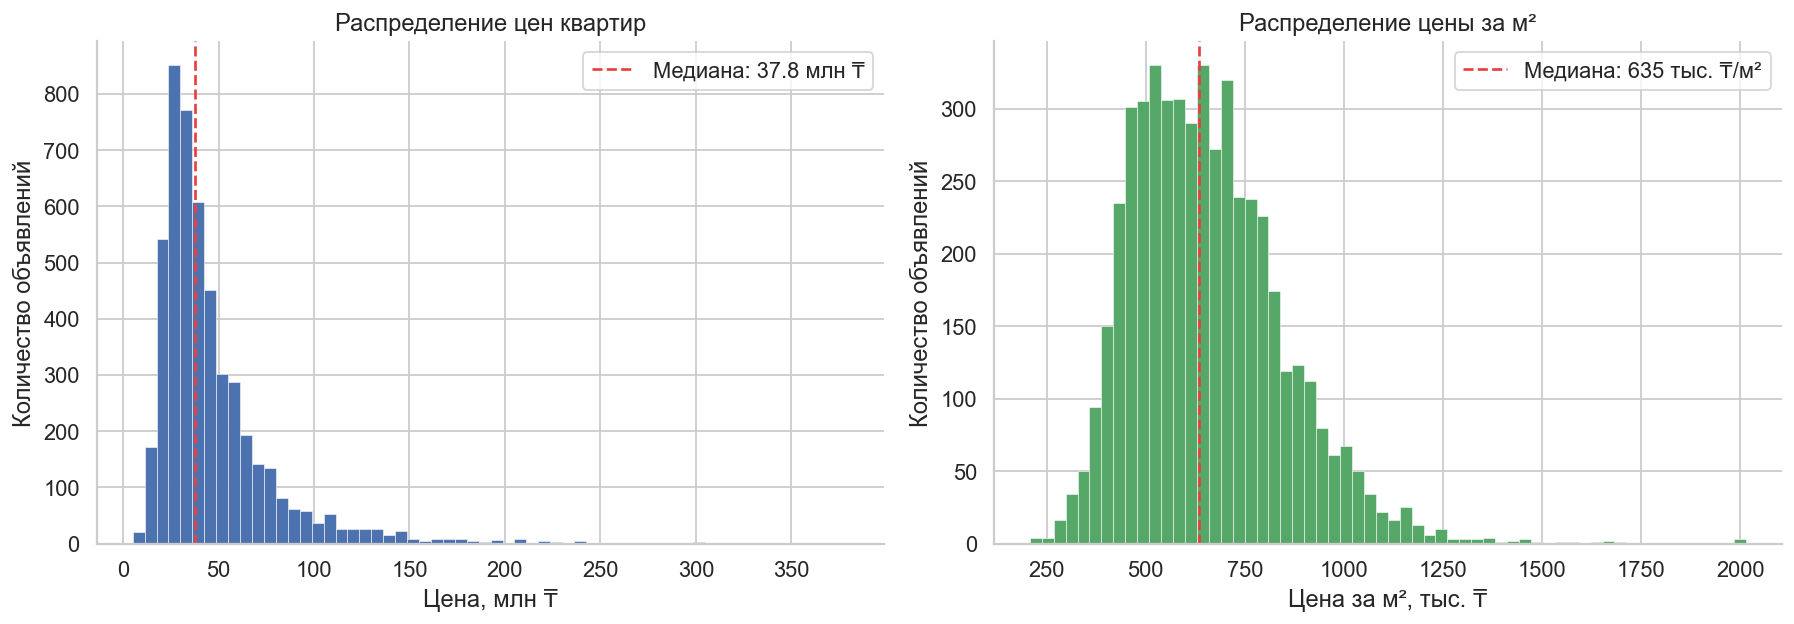

Медианная цена:    37.79 млн ₸
Медиана цены/м²:   634,960 ₸


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Цена в млн тенге
axes[0].hist(df['price'] / 1_000_000, bins=60, color='#4C72B0', edgecolor='white', linewidth=0.3)
axes[0].set_title('Распределение цен квартир')
axes[0].set_xlabel('Цена, млн ₸')
axes[0].set_ylabel('Количество объявлений')
med = df['price'].median() / 1_000_000
axes[0].axvline(med, color='#E84040', linestyle='--', label=f'Медиана: {med:.1f} млн ₸')
axes[0].legend()

# Цена за м²
axes[1].hist(df['price_per_m2'] / 1_000, bins=60, color='#55A868', edgecolor='white', linewidth=0.3)
axes[1].set_title('Распределение цены за м²')
axes[1].set_xlabel('Цена за м², тыс. ₸')
axes[1].set_ylabel('Количество объявлений')
med_m2 = df['price_per_m2'].median() / 1_000
axes[1].axvline(med_m2, color='#E84040', linestyle='--', label=f'Медиана: {med_m2:.0f} тыс. ₸/м²')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_price_distribution.png', bbox_inches='tight')
plt.show()

print(f'Медианная цена:    {df["price"].median()/1_000_000:.2f} млн ₸')
print(f'Медиана цены/м²:   {df["price_per_m2"].median():,.0f} ₸')

## 4. Анализ по районам — Вопрос 1

In [37]:
# Статистика по районам (только районы с ≥ 20 объявлений)
district_stats = (
    df.groupby('district')
    .agg(
        count         = ('price', 'count'),
        median_price  = ('price', 'median'),
        median_pm2    = ('price_per_m2', 'median'),
        median_area   = ('area', 'median'),
        q25_price     = ('price', lambda x: x.quantile(0.25)),
        q75_price     = ('price', lambda x: x.quantile(0.75)),
    )
    .query('count >= 20')
    .sort_values('median_pm2', ascending=False)
)
district_stats

,count,median_price,median_pm2,median_area,q25_price,q75_price
district,,,,,,
"Есильский район, Астана, Казахстан",1327,"47,000,000","725,000",68,"34,200,000","71,668,820"
"Нуринский район, Астана, Казахстан",1486,"39,045,750","697,674",61,"29,900,000","55,000,000"
"Астана, Казахстан",174,"36,500,000","620,909",60,"26,850,000","51,000,000"
"Сарыаркинский район, Астана, Казахстан",1017,"30,000,000","538,462",57,"22,500,000","42,207,000"
"Алматинский район, Астана, Казахстан",777,"33,000,000","530,303",64,"25,000,000","45,000,000"
"Байконурский район, Астана, Казахстан",211,"34,000,000","476,839",68,"26,000,000","45,000,000"


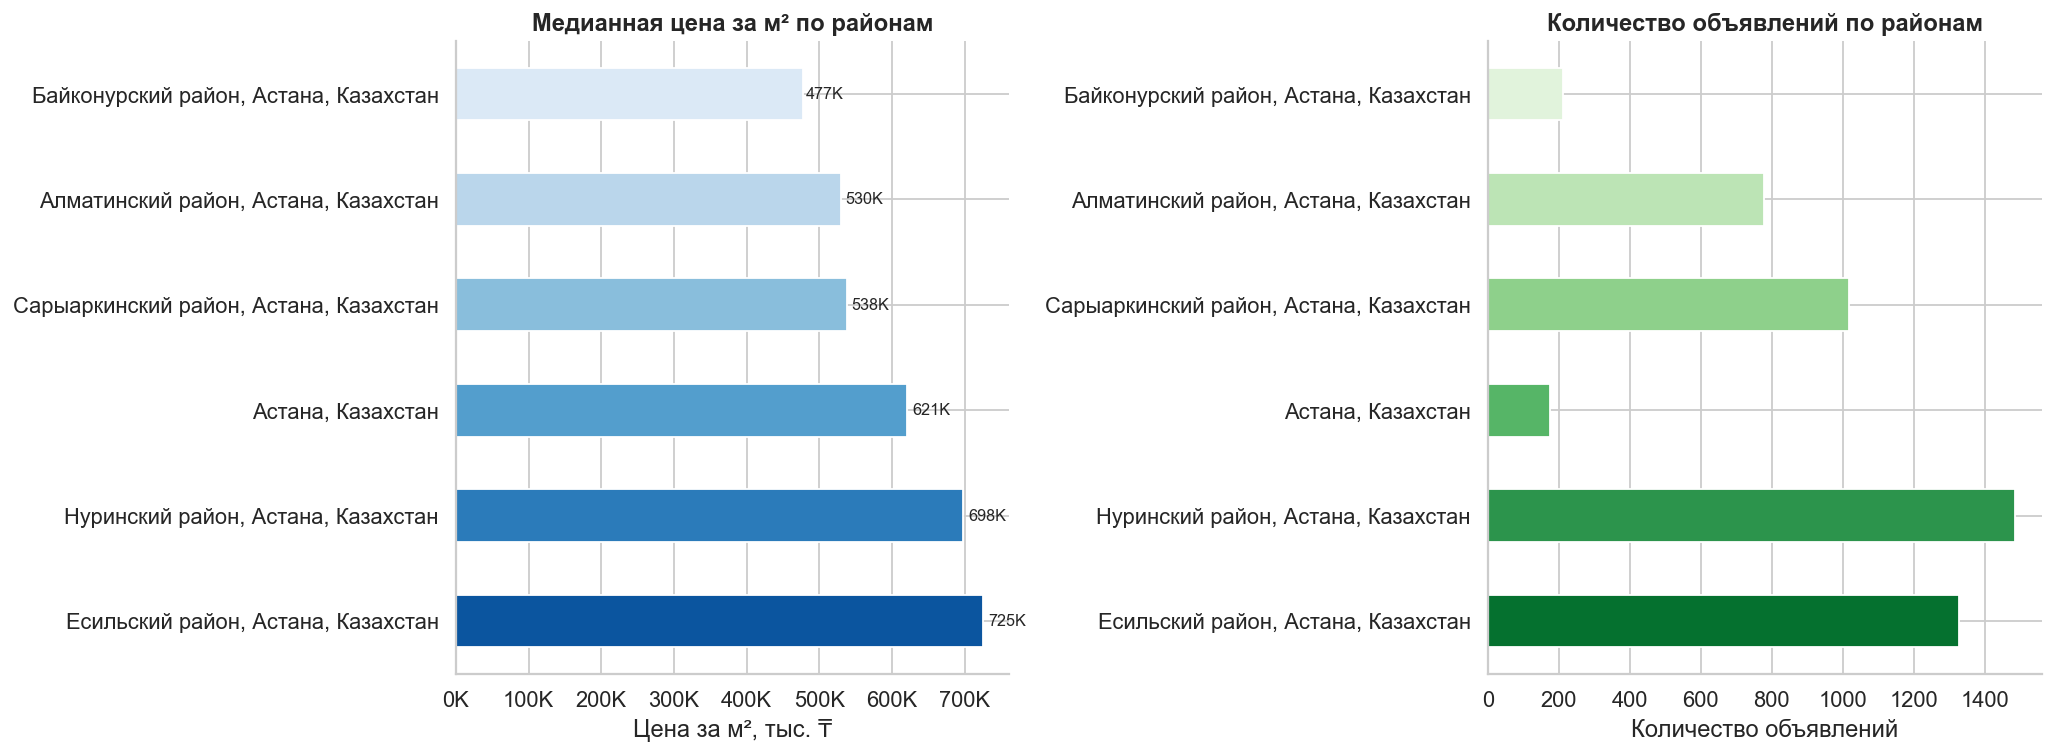

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pal = sns.color_palette('Blues_r', len(district_stats))

# Медиана цены за м²
district_stats['median_pm2'].plot(
    kind='barh', ax=axes[0], color=pal, edgecolor='white'
)
axes[0].set_title('Медианная цена за м² по районам', fontweight='bold')
axes[0].set_xlabel('Цена за м², тыс. ₸')
axes[0].xaxis.set_major_formatter(FMT_K)
axes[0].set_ylabel('')

# Добавляем подписи
for i, (_, row) in enumerate(district_stats.iterrows()):
    axes[0].text(row['median_pm2'] * 1.01, i,
                 f"{row['median_pm2']/1000:.0f}K",
                 va='center', fontsize=9)

# Объём объявлений
district_stats['count'].plot(
    kind='barh', ax=axes[1],
    color=sns.color_palette('Greens_r', len(district_stats)),
    edgecolor='white'
)
axes[1].set_title('Количество объявлений по районам', fontweight='bold')
axes[1].set_xlabel('Количество объявлений')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('02_district_analysis.png', bbox_inches='tight')
plt.show()

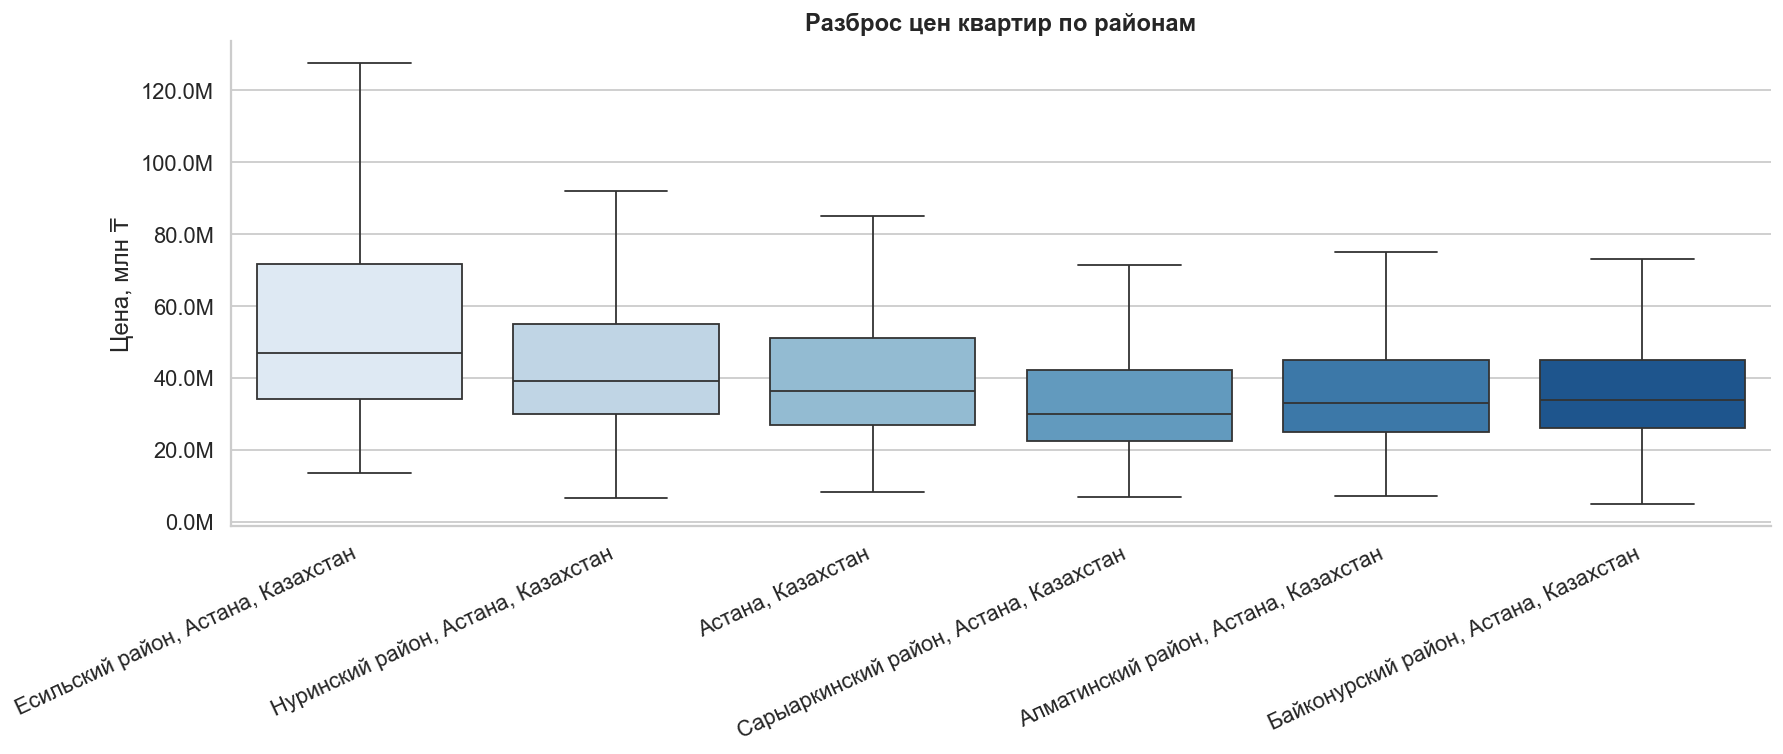

In [39]:
# Boxplot цен по районам — видна вариативность внутри каждого района
order = district_stats.index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df[df['district'].isin(order)],
    x='district', y='price',
    order=order, palette='Blues',
    showfliers=False
)
plt.title('Разброс цен квартир по районам', fontweight='bold')
plt.xlabel('')
plt.ylabel('Цена, млн ₸')
plt.gca().yaxis.set_major_formatter(FMT_MLN)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('03_district_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Площадь и комнатность — Вопрос 2

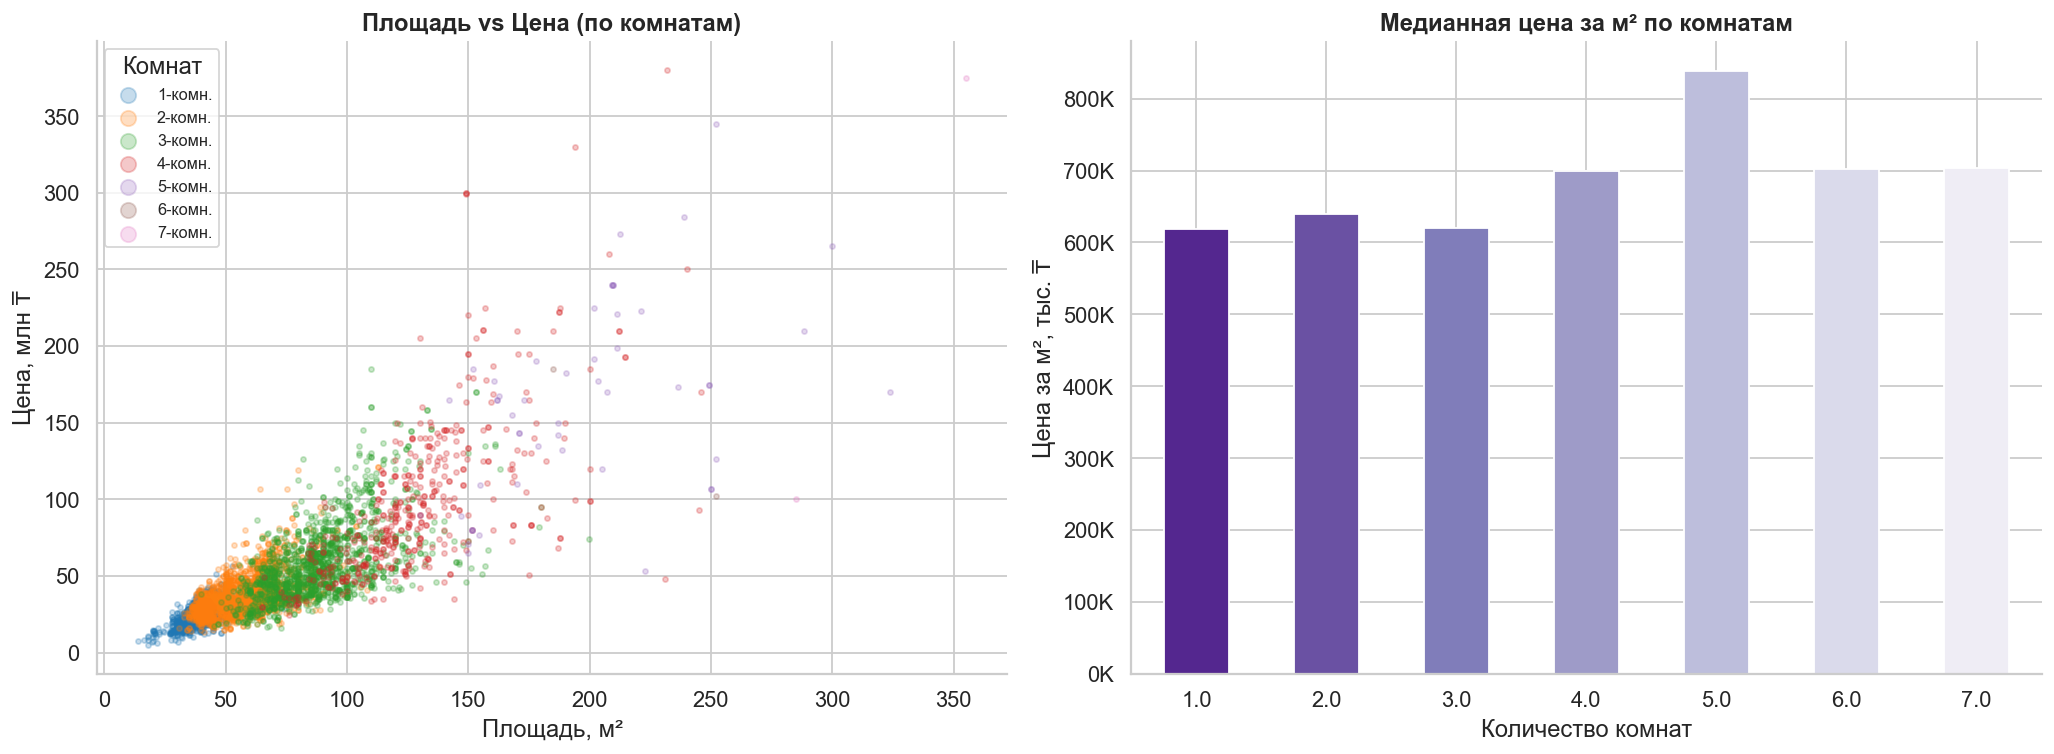

Медиана цены за м² по количеству комнат:
rooms
1    618,932 ₸
2    638,919 ₸
3    620,000 ₸
4    699,913 ₸
5    838,000 ₸
6    702,381 ₸
7    703,608 ₸
Name: price_per_m2, dtype: object


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('tab10')

# Scatter: площадь vs цена, цвет по комнатам
for i, (rooms_n, grp) in enumerate(df.groupby('rooms')):
    axes[0].scatter(
        grp['area'], grp['price'] / 1_000_000,
        alpha=0.25, s=8,
        color=palette[i % len(palette)],
        label=f'{int(rooms_n)}-комн.'
    )
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, млн ₸')
axes[0].set_title('Площадь vs Цена (по комнатам)', fontweight='bold')
axes[0].legend(title='Комнат', markerscale=3, fontsize=9)

# Медиана цены за м² по комнатам
rooms_pm2 = df.groupby('rooms')['price_per_m2'].median()
rooms_pm2.plot(
    kind='bar', ax=axes[1],
    color=sns.color_palette('Purples_r', len(rooms_pm2)),
    edgecolor='white'
)
axes[1].set_title('Медианная цена за м² по комнатам', fontweight='bold')
axes[1].set_xlabel('Количество комнат')
axes[1].set_ylabel('Цена за м², тыс. ₸')
axes[1].yaxis.set_major_formatter(FMT_K)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('04_area_rooms.png', bbox_inches='tight')
plt.show()

print('Медиана цены за м² по количеству комнат:')
print(rooms_pm2.apply(lambda x: f'{x:,.0f} ₸'))

## 6. Новостройка vs Вторичка — Вопрос 3

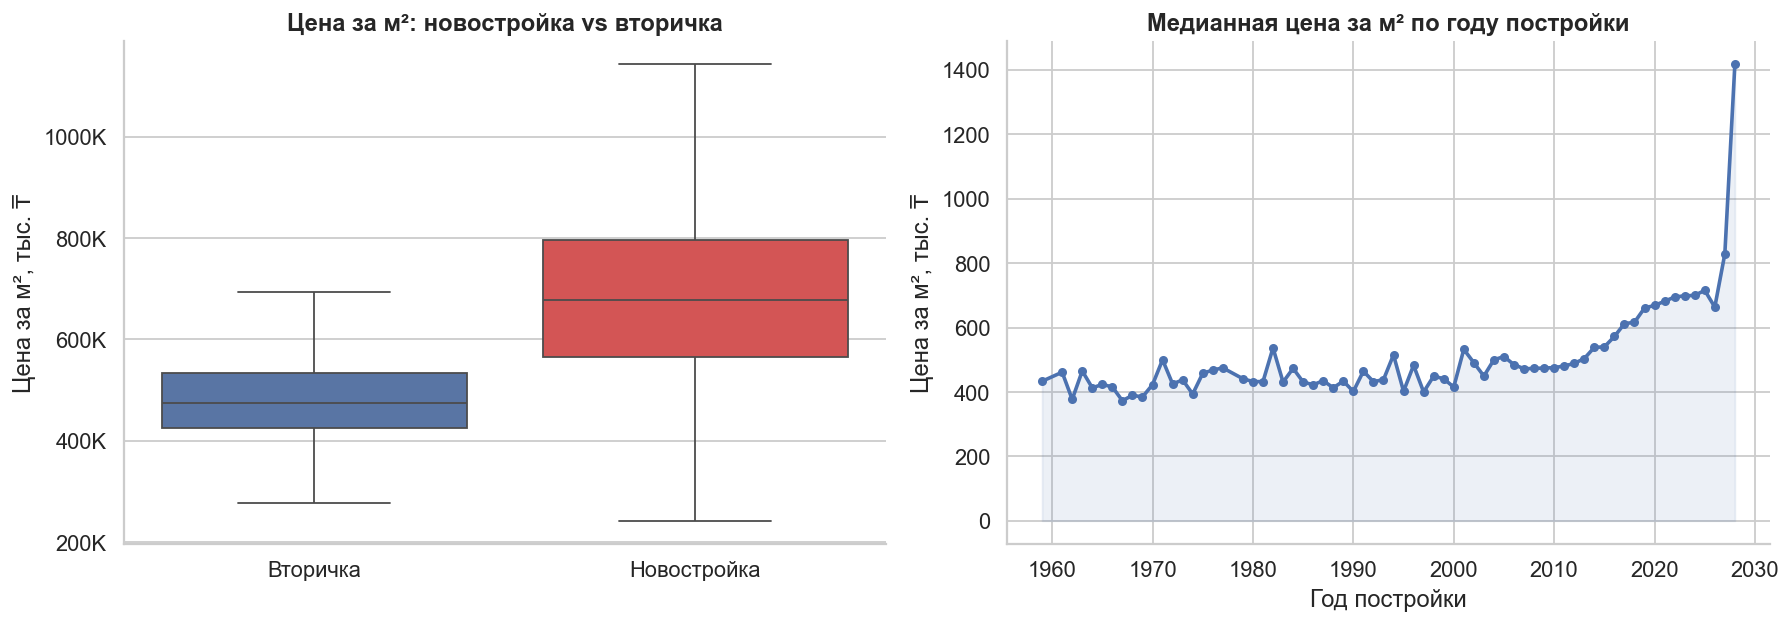

Медиана цены/м² новостройки:  677,682 ₸
Медиана цены/м² вторички:     474,702 ₸
Новостройки дороже на:         +42.8%


In [41]:
if 'is_new' not in df.columns:
    print('Колонка year_built отсутствует, вопрос пропущен')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    labels = {False: 'Вторичка', True: 'Новостройка'}
    df['market_type'] = df['is_new'].map(labels)

    # Boxplot
    sns.boxplot(
        data=df.dropna(subset=['market_type']),
        x='market_type', y='price_per_m2',
        palette={'Вторичка': '#4C72B0', 'Новостройка': '#E84040'},
        showfliers=False, ax=axes[0]
    )
    axes[0].set_title('Цена за м²: новостройка vs вторичка', fontweight='bold')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Цена за м², тыс. ₸')
    axes[0].yaxis.set_major_formatter(FMT_K)

    # Год постройки vs цена за м²
    year_pm2 = df.groupby('year_built')['price_per_m2'].median().reset_index()
    axes[1].plot(year_pm2['year_built'], year_pm2['price_per_m2'] / 1000,
                 color='#4C72B0', linewidth=2, marker='o', markersize=4)
    axes[1].set_title('Медианная цена за м² по году постройки', fontweight='bold')
    axes[1].set_xlabel('Год постройки')
    axes[1].set_ylabel('Цена за м², тыс. ₸')
    axes[1].fill_between(year_pm2['year_built'], year_pm2['price_per_m2'] / 1000,
                         alpha=0.1, color='#4C72B0')

    plt.tight_layout()
    plt.savefig('05_new_vs_secondary.png', bbox_inches='tight')
    plt.show()

    # Численная разница
    med_new = df[df['is_new'] == True]['price_per_m2'].median()
    med_old = df[df['is_new'] == False]['price_per_m2'].median()
    diff_pct = (med_new / med_old - 1) * 100
    print(f'Медиана цены/м² новостройки:  {med_new:,.0f} ₸')
    print(f'Медиана цены/м² вторички:     {med_old:,.0f} ₸')
    print(f'Новостройки дороже на:         {diff_pct:+.1f}%')

## 7. Влияние этажа — Вопрос 4

                Медиана цены/м²  Кол-во vs средние
Первый этаж             507,843     185     -21.5%
Средние этажи           647,321    4377      +0.0%
Последний этаж          549,611     430     -15.1%


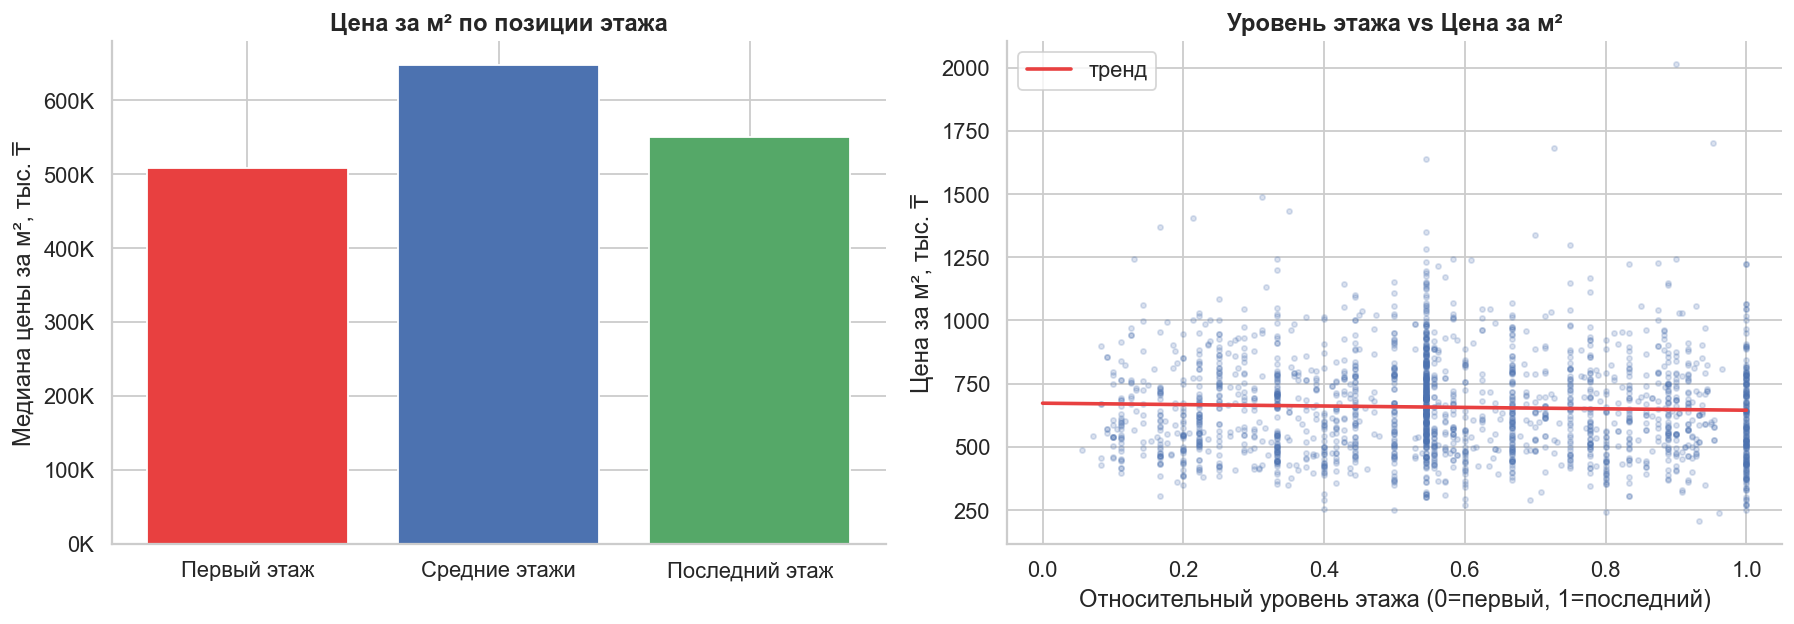

In [42]:
if 'floor_ratio' not in df.columns:
    print('Колонки floor/floor_total отсутствуют, вопрос пропущен')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Первый / последний / средние
    floor_groups = {
        'Первый этаж':   df[df['is_first_floor']]['price_per_m2'],
        'Средние этажи': df[~df['is_first_floor'] & ~df['is_last_floor']]['price_per_m2'],
        'Последний этаж':df[df['is_last_floor']]['price_per_m2'],
    }
    floor_summary = pd.DataFrame({
        'Медиана цены/м²': {k: v.median() for k, v in floor_groups.items()},
        'Кол-во': {k: len(v) for k, v in floor_groups.items()},
    })

    base_med = floor_summary.loc['Средние этажи', 'Медиана цены/м²']
    floor_summary['vs средние'] = (
        (floor_summary['Медиана цены/м²'] / base_med - 1) * 100
    ).apply(lambda x: f'{x:+.1f}%')
    print(floor_summary.to_string())

    # Bar: сравнение трёх типов
    meds = [v.median() for v in floor_groups.values()]
    colors = ['#E84040', '#4C72B0', '#55A868']
    axes[0].bar(floor_groups.keys(), meds, color=colors, edgecolor='white')
    axes[0].set_title('Цена за м² по позиции этажа', fontweight='bold')
    axes[0].set_ylabel('Медиана цены за м², тыс. ₸')
    axes[0].yaxis.set_major_formatter(FMT_K)

    # Scatter: floor_ratio vs price_per_m2
    sample = df[['floor_ratio', 'price_per_m2']].dropna().sample(min(2000, len(df)), random_state=42)
    axes[1].scatter(sample['floor_ratio'], sample['price_per_m2'] / 1000,
                    alpha=0.2, s=8, color='#4C72B0')
    # Тренд
    z = np.polyfit(sample['floor_ratio'], sample['price_per_m2'] / 1000, 1)
    p = np.poly1d(z)
    xs = np.linspace(0, 1, 100)
    axes[1].plot(xs, p(xs), color='#E84040', linewidth=2, label='тренд')
    axes[1].set_xlabel('Относительный уровень этажа (0=первый, 1=последний)')
    axes[1].set_ylabel('Цена за м², тыс. ₸')
    axes[1].set_title('Уровень этажа vs Цена за м²', fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('06_floor_analysis.png', bbox_inches='tight')
    plt.show()

## 8. Бюджет на 2-комнатную по районам — Вопрос 5

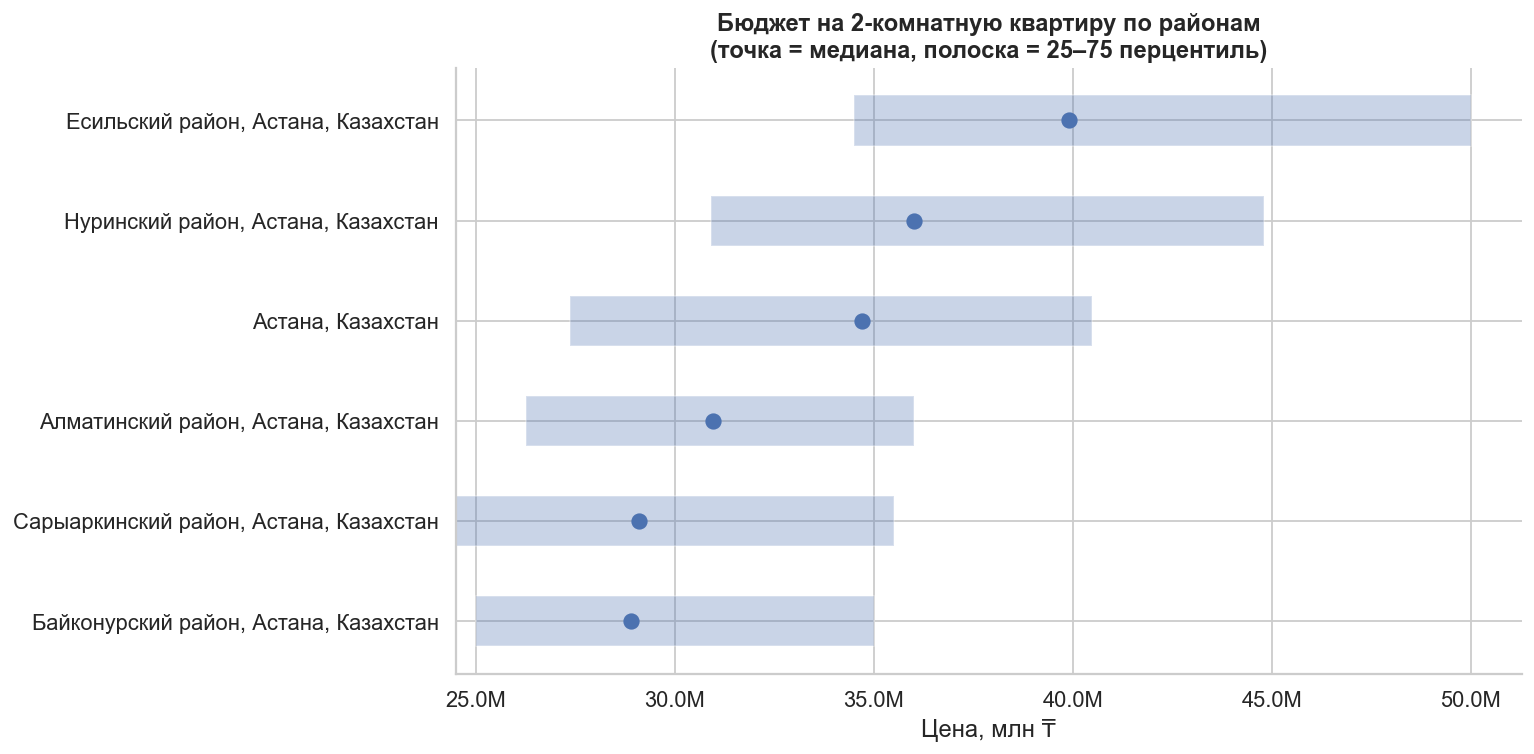

In [43]:
df_2room = df[df['rooms'] == 2].copy()

budget = (
    df_2room.groupby('district')['price']
    .agg(['median', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75), 'count'])
    .rename(columns={'median': 'Медиана', '<lambda_0>': 'Q25', '<lambda_1>': 'Q75', 'count': 'count'})
)
budget = budget[budget['count'] >= 10].sort_values('Медиана')

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(budget))

for i, (idx, row) in enumerate(budget.iterrows()):
    ax.barh(i, row['Q75'] - row['Q25'], left=row['Q25'],
            height=0.5, color='#4C72B0', alpha=0.3)
    ax.plot(row['Медиана'], i, 'o', color='#4C72B0', markersize=8, zorder=5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(budget.index)
ax.set_title('Бюджет на 2-комнатную квартиру по районам\n(точка = медиана, полоска = 25–75 перцентиль)',
             fontweight='bold')
ax.set_xlabel('Цена, млн ₸')
ax.xaxis.set_major_formatter(FMT_MLN)
plt.tight_layout()
plt.savefig('07_budget_2room.png', bbox_inches='tight')
plt.show()

## 9. Корреляционная матрица

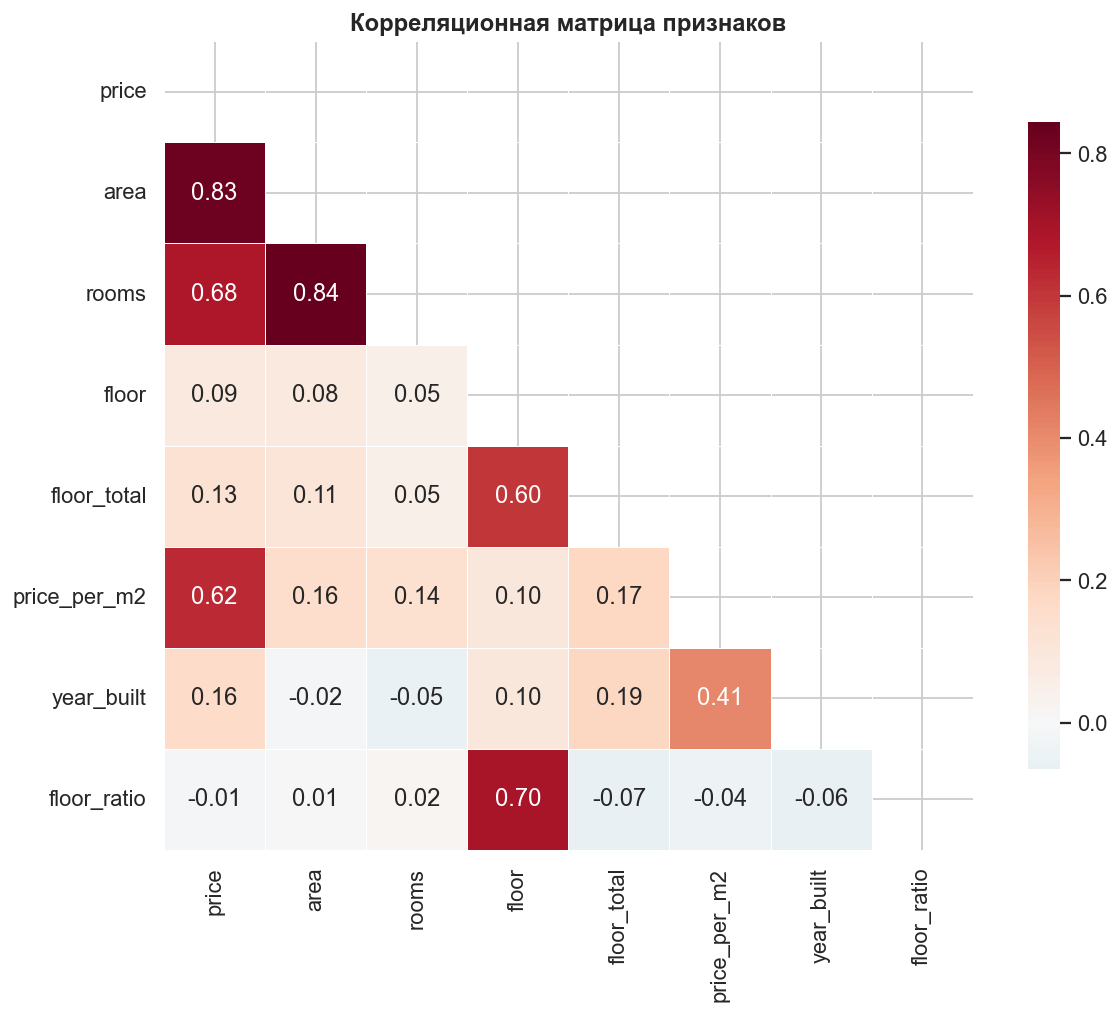

In [44]:
numeric_cols = ['price', 'area', 'rooms', 'floor', 'floor_total', 'price_per_m2']
if 'year_built' in df.columns: numeric_cols.append('year_built')
if 'floor_ratio' in df.columns: numeric_cols.append('floor_ratio')

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Корреляционная матрица признаков', fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation.png', bbox_inches='tight')
plt.show()

## 10. Модель предсказания цены — Вопрос 6

In [45]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Признаки
feature_cols = ['area', 'rooms', 'floor', 'floor_total']
if 'year_built' in df.columns:    feature_cols.append('year_built')
if 'is_new' in df.columns:        feature_cols.append('is_new')
if 'is_first_floor' in df.columns: feature_cols.append('is_first_floor')
if 'is_last_floor' in df.columns:  feature_cols.append('is_last_floor')
if 'floor_ratio' in df.columns:    feature_cols.append('floor_ratio')

model_df = df.dropna(subset=feature_cols + ['price', 'district']).copy()

le = LabelEncoder()
model_df['district_enc'] = le.fit_transform(model_df['district'])
feature_cols_enc = feature_cols + ['district_enc']

X = model_df[feature_cols_enc].astype(float)
y = model_df['price']

print(f'Размер обучающей выборки: {len(X):,} строк, {len(feature_cols_enc)} признаков')

Размер обучающей выборки: 4,992 строк, 10 признаков


In [46]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=100),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=4,
        learning_rate=0.05, random_state=42
    ),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae_scores = -cross_val_score(model, X, y, cv=kf,
                                   scoring='neg_mean_absolute_error')
    results[name] = {
        'R² (mean)': scores.mean(),
        'R² (std)':  scores.std(),
        'MAE mean':  mae_scores.mean(),
    }
    print(f'{name:25s} R²={scores.mean():.3f} ± {scores.std():.3f}   '
          f'MAE={mae_scores.mean()/1_000_000:.2f} млн ₸')

Linear Regression         R²=0.726 ± 0.026   MAE=10.75 млн ₸
Ridge                     R²=0.725 ± 0.026   MAE=10.71 млн ₸
Gradient Boosting         R²=0.822 ± 0.026   MAE=7.87 млн ₸


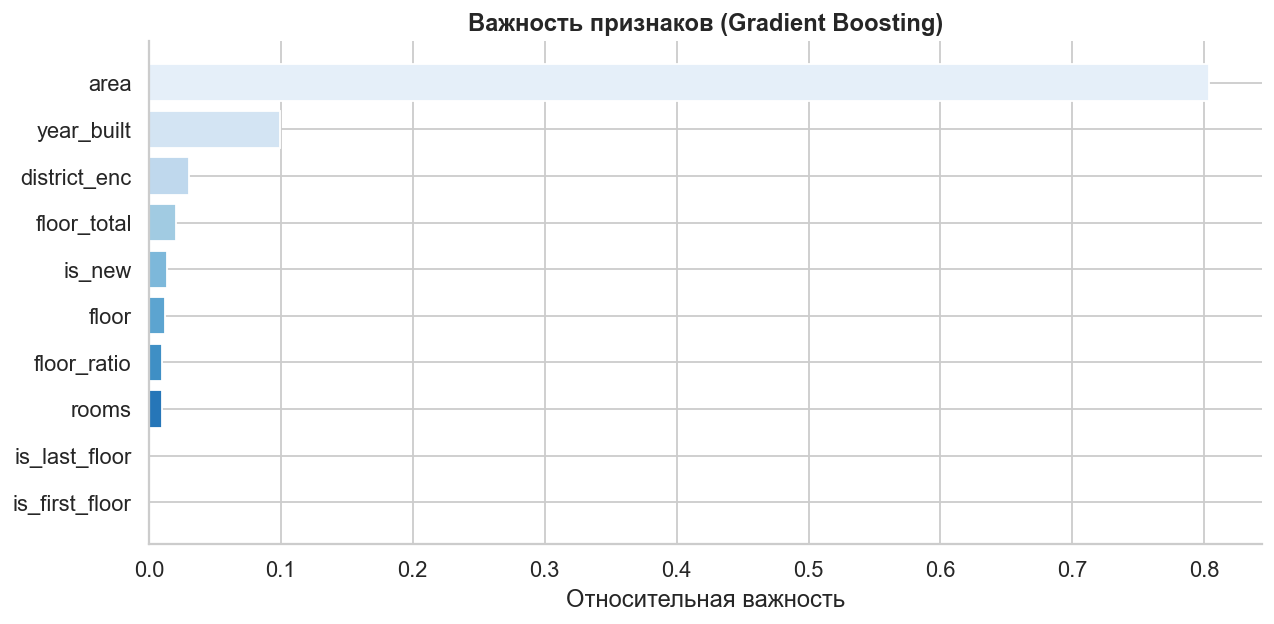

In [47]:
# Финальная модель — Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
)
gb.fit(X, y)

# Feature importance
importance_df = pd.DataFrame({
    'Признак':  feature_cols_enc,
    'Важность': gb.feature_importances_
}).sort_values('Важность', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    importance_df['Признак'],
    importance_df['Важность'],
    color=sns.color_palette('Blues_r', len(importance_df)),
    edgecolor='white'
)
ax.set_title('Важность признаков (Gradient Boosting)', fontweight='bold')
ax.set_xlabel('Относительная важность')
plt.tight_layout()
plt.savefig('09_feature_importance.png', bbox_inches='tight')
plt.show()

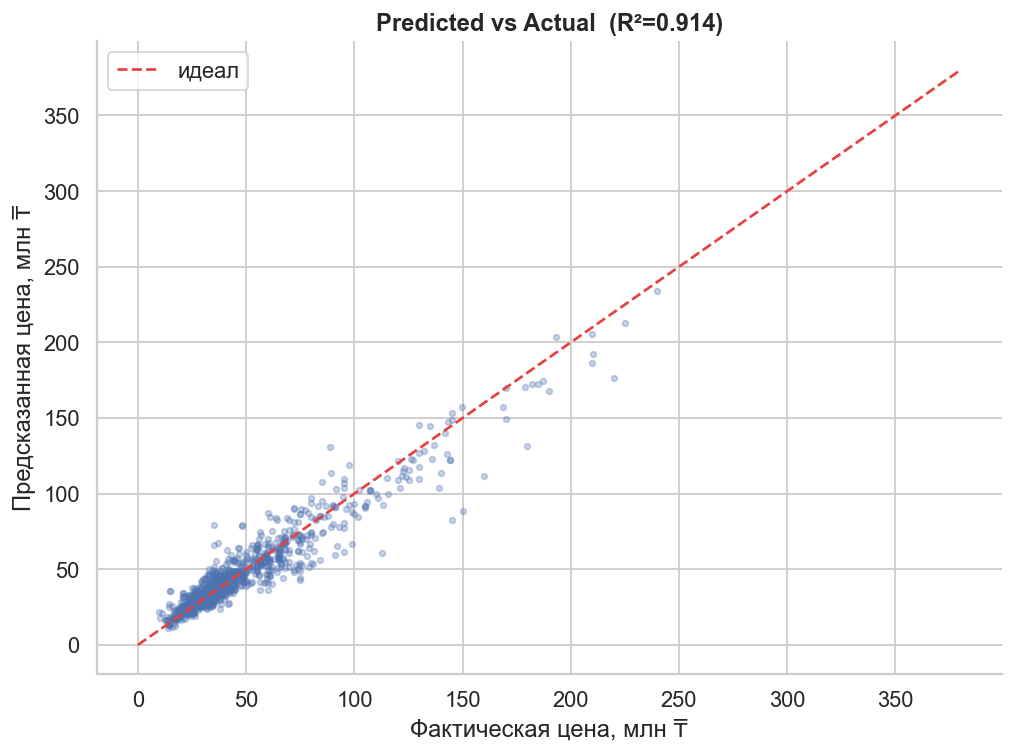

R²  = 0.914
MAE = 6.39 млн ₸


In [48]:
# Predicted vs Actual
y_pred = gb.predict(X)

fig, ax = plt.subplots(figsize=(8, 6))
sample_idx = np.random.choice(len(y), size=min(1000, len(y)), replace=False)
ax.scatter(
    y.iloc[sample_idx] / 1_000_000,
    y_pred[sample_idx] / 1_000_000,
    alpha=0.3, s=10, color='#4C72B0'
)
lims = [0, max(y.max(), y_pred.max()) / 1_000_000]
ax.plot(lims, lims, color='#E84040', linewidth=1.5, linestyle='--', label='идеал')
ax.set_xlabel('Фактическая цена, млн ₸')
ax.set_ylabel('Предсказанная цена, млн ₸')
ax.set_title(f'Predicted vs Actual  (R²={r2_score(y, y_pred):.3f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('10_predicted_vs_actual.png', bbox_inches='tight')
plt.show()

print(f'R²  = {r2_score(y, y_pred):.3f}')
print(f'MAE = {mean_absolute_error(y, y_pred)/1_000_000:.2f} млн ₸')

##  Ключевые находки

###  Районы
- Самый дорогой район по цене за м²: **Есильский — 725 000 ₸/м²**
- Самый доступный: **Байконурский — 476 839 ₸/м²**
- Разница между самым дорогим и доступным районом: **+52%**

###  Площадь и комнатность
- Медианная площадь квартир: 57–68 м² в зависимости от района
- Есильский район — самый компактный по медиане площади (68 м²) и самый дорогой

###  Новостройка vs Вторичка
- Новостройки (≥2015) дороже вторичного жилья на **+42.8%**
- Медиана цены/м² новостройки: **677 682 ₸**, вторички: **474 702 ₸**

###  Этаж
- Первый этаж: дисконт **−21.5%** от медианы (507 843 ₸/м²)
- Последний этаж: дисконт **−15.1%** (549 611 ₸/м²)
- Средние этажи — оптимальная цена: **647 321 ₸/м²**

###  Бюджет на 2-комнатную
- Самый доступный район (Байконурский): медиана **~29 млн ₸**
- Медиана по городу: **~35 млн ₸**
- Самый дорогой район (Есильский): медиана **~40 млн ₸**

###  Модель
- Лучшая модель: **Gradient Boosting**
- R² = **0.914** — модель объясняет **91.4%** вариации цены
- MAE = **6.39 млн ₸** — средняя ошибка предсказания
- Главные факторы: **площадь, район, количество комнат**